<a href="https://colab.research.google.com/github/Mohit2422005/atri-ai/blob/main/fashion_mnist_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
# QS 1 : load Fashion-MNIST and plot one example per class

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

In [90]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)


(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [91]:
images=[]
for i in range(10):
  arr=np.where(y_train==i)[0][0]
  images.append(x_train[arr])

In [92]:
print(len(images))
print(images[0].shape)
print(images[9].shape)

10
(28, 28)
(28, 28)


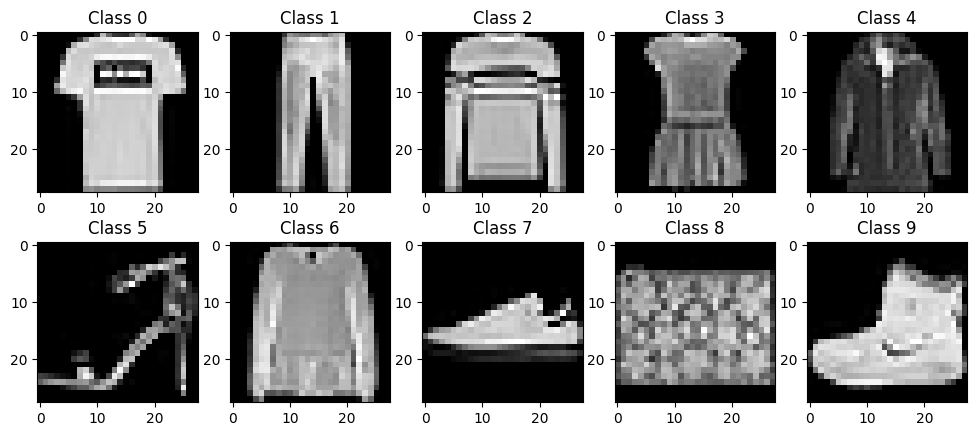

In [93]:
fig,axes=plt.subplots(2,5,figsize=(12,5))
axes_flat=axes.flatten()
for i in range(10):
  axes_flat[i].set_title(f'Class {i}')
  axes_flat[i].imshow(images[i],cmap='gray')


In [94]:
# QS 2 :Implement a feedforward neural network that takes images from the Fashion-MNIST

In [95]:
batch = x_train[:32]
print(batch.shape)

(32, 28, 28)


In [96]:
batch_flat = batch.reshape(32, 784)
print(batch_flat.shape)

(32, 784)


In [97]:
batch_final = batch_flat.T
print(batch_final.shape)

(784, 32)


In [98]:
def relu(z):
  return np.maximum(0,z)

In [99]:
def softmax(z):
  z_shifted = z-np.max(z,axis=0,keepdims=True)
  exp_z = np.exp(z_shifted)
  return exp_z/np.sum(exp_z,axis=0,keepdims=True)


In [133]:
class nueralnetwork:
  def __init__(self,layer_size,activation='relu',init_method='random',loss_type='cross_entropy'):
    self.layer_size=layer_size
    self.activation=activation
    self.weights=[]
    self.biases=[]
    self.init_method=init_method
    self.loss_type=loss_type

    for i in range(1,len(layer_size)):
      input_size=layer_size[i-1]
      output_size=layer_size[i]
      if init_method=='random':
        w=np.random.randn(output_size,input_size)*0.01
        b=np.zeros((output_size,1))
      elif init_method=='xavier':
        w=np.random.randn(output_size,input_size)/np.sqrt(input_size)
        b=np.zeros((output_size,1))
      self.weights.append(w)
      self.biases.append(b)

  def forward_pass(self,batch):
    a=batch
    self. activations=[a]
    self. z_values=[]
    num_layers=len(self.weights)
    for i in range(num_layers):
      z=np.dot(self.weights[i],a)+self.biases[i]
      self.z_values.append(z)
      if i==num_layers-1:
        a=softmax(z)
      else:
        if self.activation=='relu':
          a=relu(z)
        elif self.activation=='tanh':
          a=tanh(z)
        elif self.activation=='sigmoid':
          a=sigmoid(z)
      self.activations.append(a)
    return a

  def backward(self,y):
    m=y.shape[1]
    num_layers=len(self.weights)
    dw=[None]*num_layers
    db=[None]*num_layers

    if self.loss_type=='cross_entropy':
      dz=self.activations[-1]-y
    elif self.loss_type=='squared_error':
      y_hat=self.activations[-1]
      dz=(y_hat-y)*y_hat*(1-y_hat)

    for i in reversed(range(num_layers)):
      a_prev=self.activations[i]
      dw[i]= np.dot(dz,a_prev.T)/m
      db[i]=np.sum(dz,axis=1,keepdims=True)/m
      if i>0:
        if self.activation=='relu':
          dz=np.dot(self.weights[i].T,dz)*relu_derivative(self.z_values[i-1])
        elif self.activation=='tanh':
          dz=np.dot(self.weights[i].T,dz)*tanh_derivative(self.z_values[i-1])
        elif self.activation=='sigmoid':
          dz=np.dot(self.weights[i].T,dz)*sigmoid_derivative(self.z_values[i-1])

    return dw,db






In [128]:
nn1 = nueralnetwork([784, 128, 64, 32, 10])
print(len(nn1.weights))
for w in nn1.weights:
    print(w.shape)

output = nn1.forward_pass(batch_final)
print(output.shape)
print(output[:, 0].sum())

4
(128, 784)
(64, 128)
(32, 64)
(10, 32)
(10, 32)
1.0


In [102]:
# QS 3

In [103]:
def relu_derivative(z):
  return(z>0).astype(float)


In [104]:
class SGD:
  def __init__(self,learning_rate=0.1):
    self.learning_rate=learning_rate
  def update(self,model,dw,db):
    num_layers=len(model.weights)
    for i in range(num_layers):
      model.weights[i] -= self.learning_rate*dw[i]
      model.biases[i] -= self.learning_rate*db[i]


In [105]:
nn1 = nueralnetwork([784, 128, 64, 32, 10])
opt = SGD(learning_rate=0.1)
X_batch = batch_final
Y_batch = np.eye(10)[y_train[:32]].T

output = nn1.forward_pass(X_batch)
loss_before = -np.sum(Y_batch * np.log(output + 1e-9)) / 32
dW, db = nn1.backward(Y_batch)
opt.update(nn1, dW, db)

output2 = nn1.forward_pass(X_batch)
loss_after = -np.sum(Y_batch * np.log(output2 + 1e-9)) / 32

print("loss before:", loss_before)
print("loss after:", loss_after)

loss before: 2.302766927465657
loss after: 2.296203885776753


In [106]:
class momentum:
  def __init__(self,learning_rate=0.1,momentum=0.9):
    self.learning_rate=learning_rate
    self.vw=None
    self.vb=None
    self.momentum=momentum
  def update(self,model,dw,db):
    num_layers=len(model.weights)
    if self.vw is None:
      self.vw=[np.zeros_like(w) for w in model.weights]
      self.vb=[np.zeros_like(b) for b in model.biases]
    for i in range(num_layers):
      self.vw[i]=self.momentum*self.vw[i]+self.learning_rate*dw[i]
      self.vb[i]=self.momentum*self.vb[i]+self.learning_rate*db[i]
      model.weights[i] -= self.vw[i]
      model.biases[i] -= self.vb[i]

In [107]:
nn2 = nueralnetwork([784, 128, 64, 32, 10])
opt2 = momentum(learning_rate=0.01, momentum=0.9)

output = nn2.forward_pass(X_batch)
loss_before = -np.sum(Y_batch * np.log(output + 1e-9)) / 32
dW, db = nn2.backward(Y_batch)
opt2.update(nn2, dW, db)

output2 = nn2.forward_pass(X_batch)
loss_after = -np.sum(Y_batch * np.log(output2 + 1e-9)) / 32

print("loss before:", loss_before)
print("loss after:", loss_after)

loss before: 2.302344927416164
loss after: 2.301653965290514


In [108]:
class RMSprop:
  def __init__(self,learning_rate=0.1,beta=0.9,epsilon=1e-8):
    self.learning_rate=learning_rate
    self.vw=None
    self.vb=None
    self.beta=beta
    self.epsilon=epsilon
  def update(self,model,dw,db):
    num_layers=len(model.weights)
    if self.vw is None:
      self.vw=[np.zeros_like(w) for w in model.weights]
      self.vb=[np.zeros_like(b) for b in model.biases]
    for i in range(num_layers):
      self.vw[i]=self.beta*self.vw[i]+(1-self.beta)*(dw[i]**2)
      self.vb[i]=self.beta*self.vb[i]+(1-self.beta)*(db[i]**2)
      model.weights[i] -= self.learning_rate * dw[i] / (np.sqrt(self.vw[i]) + self.epsilon)
      model.biases[i] -= self.learning_rate * db[i] / (np.sqrt(self.vb[i]) + self.epsilon)





In [109]:
nn3 = nueralnetwork([784, 128, 64, 32, 10])
opt3 = momentum(learning_rate=0.01, momentum=0.9)

output = nn3.forward_pass(X_batch)
loss_before = -np.sum(Y_batch * np.log(output + 1e-9)) / 32
dW, db = nn3.backward(Y_batch)
opt3.update(nn3, dW, db)

output2 = nn3.forward_pass(X_batch)
loss_after = -np.sum(Y_batch * np.log(output2 + 1e-9)) / 32

print("loss before:", loss_before)
print("loss after:", loss_after)

loss before: 2.302677665202051
loss after: 2.3019465582168284


In [110]:
class Adam:
  def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    self.learning_rate = learning_rate
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.vw = None
    self.vb = None
    self.sw = None
    self.sb = None
    self.t = 0

  def update(self, model, dw, db):
    num_layers = len(model.weights)
    if self.vw is None:
      self.vw = [np.zeros_like(w) for w in model.weights]
      self.vb = [np.zeros_like(b) for b in model.biases]
      self.sw = [np.zeros_like(w) for w in model.weights]
      self.sb = [np.zeros_like(b) for b in model.biases]
    self.t += 1
    for i in range(num_layers):
      self.vw[i] = self.beta1*self.vw[i] + (1-self.beta1)*dw[i]
      self.vb[i] = self.beta1*self.vb[i] + (1-self.beta1)*db[i]
      self.sw[i] = self.beta2*self.sw[i] + (1-self.beta2)*(dw[i]**2)
      self.sb[i] = self.beta2*self.sb[i] + (1-self.beta2)*(db[i]**2)

      vw_hat = self.vw[i] / (1 - self.beta1**self.t)
      vb_hat = self.vb[i] / (1 - self.beta1**self.t)
      sw_hat = self.sw[i] / (1 - self.beta2**self.t)
      sb_hat = self.sb[i] / (1 - self.beta2**self.t)

      model.weights[i] -= self.learning_rate * vw_hat / (np.sqrt(sw_hat) + self.epsilon)
      model.biases[i]  -= self.learning_rate * vb_hat / (np.sqrt(sb_hat) + self.epsilon)

In [111]:
nn4 = nueralnetwork([784, 128, 64, 32, 10])
opt4 = Adam(learning_rate=0.01)

output = nn4.forward_pass(X_batch)
loss_before = -np.sum(Y_batch * np.log(output + 1e-9)) / 32
dW, db = nn4.backward(Y_batch)
opt4.update(nn4, dW, db)

output3 = nn4.forward_pass(X_batch)
loss_after = -np.sum(Y_batch * np.log(output3 + 1e-9)) / 32

print("loss before:", loss_before)
print("loss after:", loss_after)

loss before: 2.303629908447653
loss after: 2.544752102610258


In [112]:
class Nesterov:
  def __init__(self, learning_rate=0.01, beta=0.9):
    self.learning_rate = learning_rate
    self.beta = beta
    self.vw = None
    self.vb = None

  def update(self, model, dw, db):
    num_layers = len(model.weights)
    if self.vw is None:
      self.vw = [np.zeros_like(w) for w in model.weights]
      self.vb = [np.zeros_like(b) for b in model.biases]
    for i in range(num_layers):
      v_prev_w = self.vw[i].copy()
      v_prev_b = self.vb[i].copy()
      self.vw[i] = self.beta*self.vw[i] - self.learning_rate*dw[i]
      self.vb[i] = self.beta*self.vb[i] - self.learning_rate*db[i]
      model.weights[i] += -self.beta*v_prev_w + (1+self.beta)*self.vw[i]
      model.biases[i]  += -self.beta*v_prev_b + (1+self.beta)*self.vb[i]

In [113]:
nn4 = nueralnetwork([784, 128, 64, 32, 10])
opt4 = Nesterov(learning_rate=0.01)
output = nn4.forward_pass(X_batch)
loss_before = -np.sum(Y_batch * np.log(output + 1e-9)) / 32
dW, db = nn4.backward(Y_batch)
opt4.update(nn4, dW, db)
output2 = nn4.forward_pass(X_batch)
loss_after = -np.sum(Y_batch * np.log(output2 + 1e-9)) / 32
print("loss before:", loss_before)
print("loss after:", loss_after)

loss before: 2.3018756303213985
loss after: 2.3006201814435783


In [114]:
class Nadam:
  def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    self.learning_rate = learning_rate
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.vw = None
    self.vb = None
    self.sw = None
    self.sb = None
    self.t = 0

  def update(self, model, dw, db):
    num_layers = len(model.weights)
    if self.vw is None:
      self.vw = [np.zeros_like(w) for w in model.weights]
      self.vb = [np.zeros_like(b) for b in model.biases]
      self.sw = [np.zeros_like(w) for w in model.weights]
      self.sb = [np.zeros_like(b) for b in model.biases]
    self.t += 1
    for i in range(num_layers):
      self.vw[i] = self.beta1*self.vw[i] + (1-self.beta1)*dw[i]
      self.vb[i] = self.beta1*self.vb[i] + (1-self.beta1)*db[i]
      self.sw[i] = self.beta2*self.sw[i] + (1-self.beta2)*(dw[i]**2)
      self.sb[i] = self.beta2*self.sb[i] + (1-self.beta2)*(db[i]**2)

      vw_hat = self.vw[i] / (1 - self.beta1**self.t)
      vb_hat = self.vb[i] / (1 - self.beta1**self.t)
      sw_hat = self.sw[i] / (1 - self.beta2**self.t)
      sb_hat = self.sb[i] / (1 - self.beta2**self.t)

      vw_nesterov = self.beta1*vw_hat + (1-self.beta1)*dw[i]/(1-self.beta1**self.t)
      vb_nesterov = self.beta1*vb_hat + (1-self.beta1)*db[i]/(1-self.beta1**self.t)

      model.weights[i] -= self.learning_rate * vw_nesterov / (np.sqrt(sw_hat) + self.epsilon)
      model.biases[i]  -= self.learning_rate * vb_nesterov / (np.sqrt(sb_hat) + self.epsilon)

In [115]:
nn5 = nueralnetwork([784, 128, 64, 32, 10])
opt5 = Nadam(learning_rate=0.01)
output = nn5.forward_pass(X_batch)
loss_before = -np.sum(Y_batch * np.log(output + 1e-9)) / 32
dW, db = nn5.backward(Y_batch)
opt5.update(nn5, dW, db)
output2 = nn5.forward_pass(X_batch)
loss_after = -np.sum(Y_batch * np.log(output2 + 1e-9)) / 32
print("loss before:", loss_before)
print("loss after:", loss_after)


loss before: 2.302058823854769
loss after: 10.233376775537092


In [116]:
# QS 4

In [117]:
!pip install wandb
import wandb
wandb.login()

True

In [118]:
val_size=int(0.1*x_train.shape[0])
x_val=x_train[:val_size]
y_val=y_train[:val_size]
x_train=x_train[val_size:]
y_train=y_train[val_size:]
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)

(54000, 28, 28) (54000,)
(6000, 28, 28) (6000,)


In [119]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [87]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [120]:
def tanh(z):
    return np.tanh(z)

In [121]:
def tanh_derivative(z):
    return 1 - np.tanh(z)**2

In [122]:
def optimizer(name,learning_rate):
  if name=="sgd":
    return SGD(learning_rate)
  elif name=="momentum":
    return momentum(learning_rate,momentum=0.1)
  elif name=="rmsprop":
    return RMSprop(learning_rate)
  elif name=="adam":
    return Adam(learning_rate)
  elif name=="nesterov":
    return Nesterov(learning_rate)
  elif name=="nadam":
    return Nadam(learning_rate)

In [123]:
def accuracy(model,x,y_true):
  output=model.forward_pass(x)
  predictions = np.argmax(output, axis=0)
  return np.mean(predictions == y_true)

In [124]:
def train_model(config=None):
  with wandb.init(config=config):
    config=wandb.config
    layer_size=[784] + [config.hidden_size]*config.num_hidden_layers + [10]
    model = nueralnetwork(layer_size, activation=config.activation, init_method=config.weight_init)
    opt = optimizer(config.optimizer, config.learning_rate)
    num_examples = x_train.shape[0]
    x_flat = x_train.reshape(num_examples, 784).T / 255.0
    y_onehot = np.eye(10)[y_train].T

    x_val_flat = x_val.reshape(x_val.shape[0], 784).T / 255.0
    y_val_int = y_val

    for epoch in range(config.epochs):
      perm = np.random.permutation(num_examples)
      x_flat_shuffled = x_flat[:, perm]
      y_onehot_shuffled = y_onehot[:, perm]
      y_int_shuffled = y_train[perm]
      batch_size = config.batch_size
      num_batches = num_examples // batch_size

      for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = (batch_idx + 1) * batch_size
        x_batch = x_flat_shuffled[:, start_idx:end_idx]
        y_batch = y_onehot_shuffled[:, start_idx:end_idx]
        y_int_batch = y_int_shuffled[start_idx:end_idx]

        output = model.forward_pass(x_batch)
        dw,db = model.backward(y_batch)

        if config.weight_decay > 0:
          for i in range(len(model.weights)):
            dw[i] += config.weight_decay * model.weights[i]
        opt.update(model,dw,db)

      train_output=model.forward_pass(x_flat_shuffled)
      train_loss=-np.sum(y_onehot_shuffled*np.log(train_output+1e-9))/num_examples
      train_acc=accuracy(model,x_flat_shuffled,y_int_shuffled)
      val_output=model.forward_pass(x_val_flat)
      val_loss=-np.sum(np.eye(10)[y_val_int].T*np.log(val_output+1e-9))/x_val.shape[0]
      val_acc=accuracy(model,x_val_flat,y_val_int)

      wandb.log({"train_loss":train_loss,"train_acc":train_acc,"val_loss":val_loss,"val_acc":val_acc})


In [134]:
test_config = {
    "hidden_size": 64,
    "num_hidden_layers": 2,
    "activation": "relu",
    "weight_init": "random",
    "optimizer": "adam",
    "learning_rate": 0.01,
    "weight_decay": 0.0,
    "epochs": 2,
    "batch_size": 32
}

train_model(config=test_config)

train_acc,▁▅▅▆▆▇████
train_loss,█▄▃▃▂▂▁▁▁▁
val_acc,▁▅▅▆▆▇████
val_loss,█▄▃▃▂▂▁▁▁▁
train_acc,0.75302
train_loss,0.58008
val_acc,0.7425
val_loss,0.6249


In [135]:
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "val_accuracy",
        "goal": "maximize"
    },
    "parameters": {
        "epochs": {"values": [5, 10]},
        "num_hidden_layers": {"values": [3, 4, 5]},
        "hidden_size": {"values": [32, 64, 128]},
        "weight_decay": {"values": [0, 0.0005, 0.5]},
        "learning_rate": {"values": [1e-3, 1e-4]},
        "optimizer": {"values": ["sgd", "momentum", "rmsprop", "adam", "nesterov", "nadam"]},
        "batch_size": {"values": [16, 32, 64]},
        "weight_init": {"values": ["random", "xavier"]},
        "activation": {"values": ["sigmoid", "tanh", "relu"]}
    }
}

In [136]:
sweep_id = wandb.sweep(sweep_config, project="fashion-mnist-nn")
wandb.agent(sweep_id, function=train_model, count=50)

Create sweep with ID: mm84q595
Sweep URL: https://wandb.ai/mohitofficial7777-misrimal-navajee-munoth-jain-college/fashion-mnist-nn/sweeps/mm84q595


wandb: Agent Starting Run: d2fuk9bn with config:
wandb: 	activation: relu
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


train_acc,▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▅▅▄▃▂▂▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,▁▁▁▂▂▃▄▅▇█
train_acc,0.10074
train_loss,2.30254
val_acc,0.09333
val_loss,2.30258


wandb: Agent Starting Run: v3yqee3z with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


train_acc,▁▅▇██
train_loss,█▅▃▂▁
val_acc,▁▅▇██
val_loss,█▅▃▂▁
train_acc,0.66802
train_loss,0.89987
val_acc,0.67817
val_loss,0.88574


...

train_acc,▁▁▁▁▁▁▁▁▁▁
train_loss,████▆▆▅▅▃▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,▁▂▃▄▄▅▆▇▇█
train_acc,0.10074
train_loss,2.30258
val_acc,0.09333
val_loss,2.30261


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: b3hkbm9t with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.5
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


train_acc,█▄▁▁▁
train_loss,▁▇███
val_acc,█▄▁▁▁
val_loss,▁▇███
train_acc,0.10011
train_loss,2.30262
val_acc,0.099
val_loss,2.30263


wandb: Agent Starting Run: x2v5o4n9 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 32
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 5
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.5
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


train_acc,▁████
train_loss,█▅▃▂▁
val_acc,█▁▁▁▁
val_loss,█▅▃▂▁
train_acc,0.10011
train_loss,2.32482
val_acc,0.099
val_loss,2.32208


In [ ]:
# QS 5

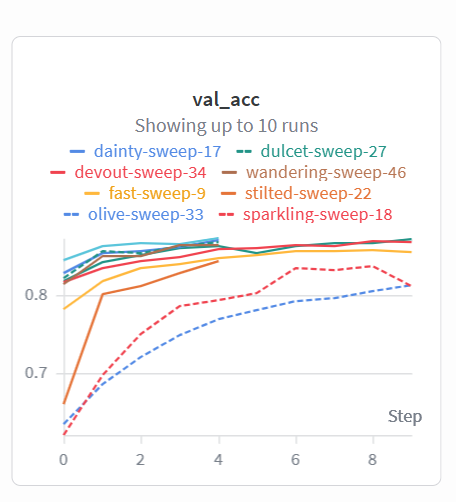

In [ ]:
# Best val_acc: 87.35%.